Overall steps in the notebook:

1. Load a single cell
2. Visualize its 3d/2d skeleton
3. Show the annotated bulbs on the 2d skel
4. Show dendritic radius vs distance (for one or mutliple branches)

In [3]:
import bulb_detection as bd
import skeliner as sk
import matplotlib.pyplot as plt
import numpy as np

In [4]:
seg_id = '720575940554533490'
skel = bd.load_skeleton('data/recalibrated skeletons/' + seg_id + '_skel_recal_75.0.pkl')

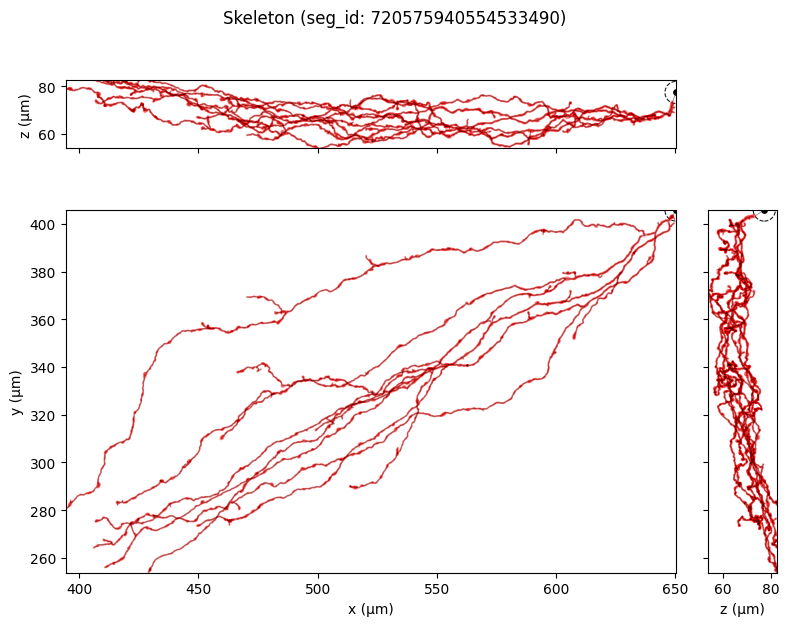

In [5]:
sk.plot3v(skel=skel, unit="μm", title=f'Skeleton (seg_id: {seg_id})')
plt.show()

In [6]:
ann = bd.parse_annotations_json('data/revised_annotations/revised_ann_' + seg_id + '.json')

In [7]:
for i,layer in enumerate(ann['layers']):
    print(i,layer['name'])

0 img
1 stroeh_mouse_retina
2 Soma ⚪️
3 k=2
4 annotated_endpoints
5 marked_branch_1
6 marked_branch_2
7 marked_branch_3
8 marked_branch_4
9 marked_branch_5
10 marked_branch_6
11 marked_branch_7


In [8]:
voxelsize = bd.io.get_layer_voxelsize(ann=ann, layer_id=3)
annotated_bulb_starts, annotated_bulb_ends = bd.io.get_annotated_bulb_coords(ann=ann, layer_id=3, voxelsize=voxelsize)

In [9]:
endpoint_coords = bd.io.get_endpoint_coords(ann=ann, layer_id=4, voxelsize=voxelsize)
endpoint_nodes = []
for endpoint_coord in endpoint_coords:
    endpoint_node, _ = bd.graph.coords_to_nodes(skel=skel, query_coords=endpoint_coord)
    endpoint_nodes.append(endpoint_node)
endpoint_nodes = np.array(endpoint_nodes)

Filter the annotations to only show the revised annotations. (This function is also useful when you want to look at annotations on a specific branch only)

In [10]:
bulb_starts_on_path, bulb_ends_on_path = bd.graph.filter_bulb_coords_by_endpoints(
    skel=skel,
    starts_coords=annotated_bulb_starts,
    ends_coords=annotated_bulb_ends,
    endpoint_nodes=endpoint_nodes
)

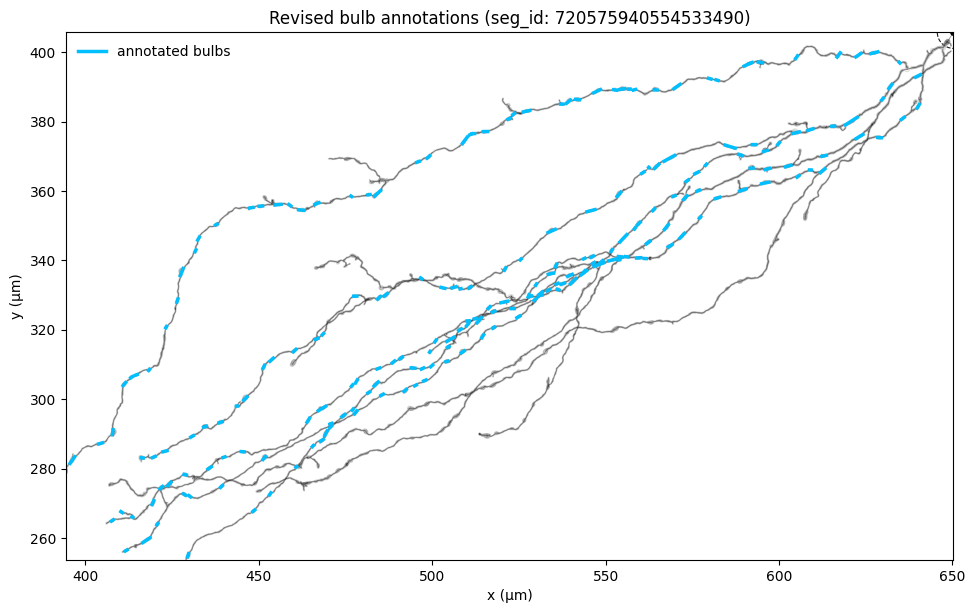

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
bd.visualization.plot_anns_on_skeleton(
    skel=skel,
    ann_stars=bulb_starts_on_path,
    ann_ends=bulb_ends_on_path,
    ax=ax,
    title=f'Revised bulb annotations (seg_id: {seg_id})'
)
plt.show()

In [12]:
# Singel branch
pruned_skel = bd.graph.prune_skeleton_from_node_ids(skel=skel, keep_node_ids=endpoint_nodes[0])

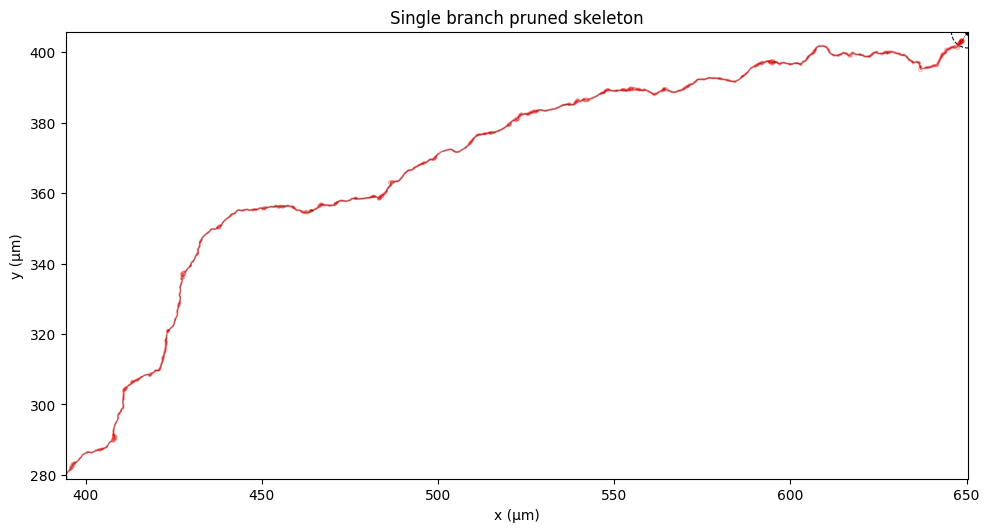

In [13]:
fig, ax = plt.subplots(figsize=(10,6))
sk.plot2d(pruned_skel, unit='μm', ax=ax)
plt.title('Single branch pruned skeleton')
plt.show()

In [14]:
# Filter annotations for that branch
bulb_starts_pruned, bulb_ends_pruned = bd.graph.filter_bulb_coords_by_endpoints(
    skel=skel,
    starts_coords=annotated_bulb_starts,
    ends_coords=annotated_bulb_ends,
    endpoint_nodes=[endpoint_nodes[0]]
)

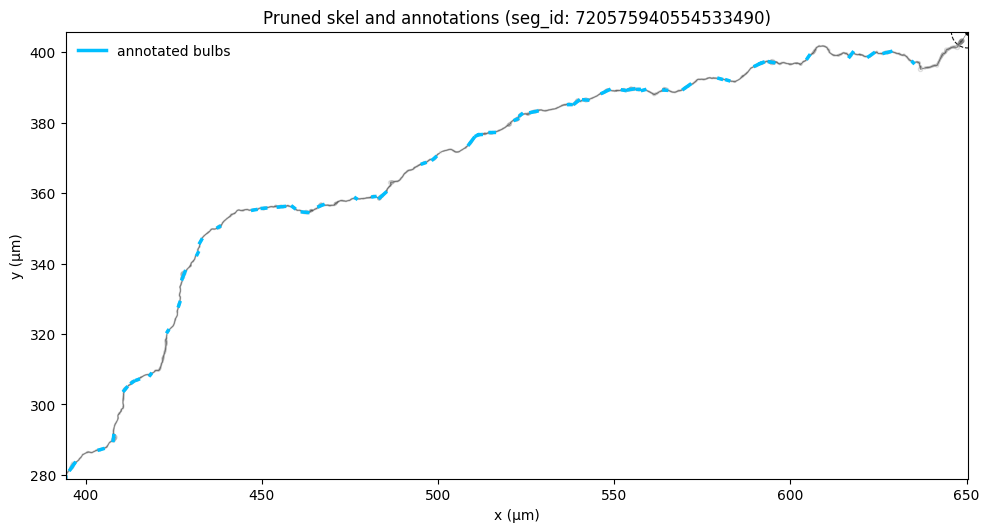

In [15]:
fig, ax = plt.subplots(figsize=(10,6))
bd.visualization.plot_anns_on_skeleton(
    skel=pruned_skel,
    ann_stars=bulb_starts_pruned,
    ann_ends=bulb_ends_pruned,
    ax=ax,
    title=f'Pruned skel and annotations (seg_id: {seg_id})'
)
plt.show()

In [16]:
start_ids_pruned, _ = bd.graph.coords_to_nodes(skel=pruned_skel, query_coords=bulb_starts_pruned)
end_ids_pruned, _ = bd.graph.coords_to_nodes(skel=pruned_skel, query_coords=bulb_ends_pruned)

In [17]:
geodesic_dists_pruned = bd.graph.compute_geodesic_distances(skel=pruned_skel)
radii_pruned = pruned_skel.radii['calibrated']

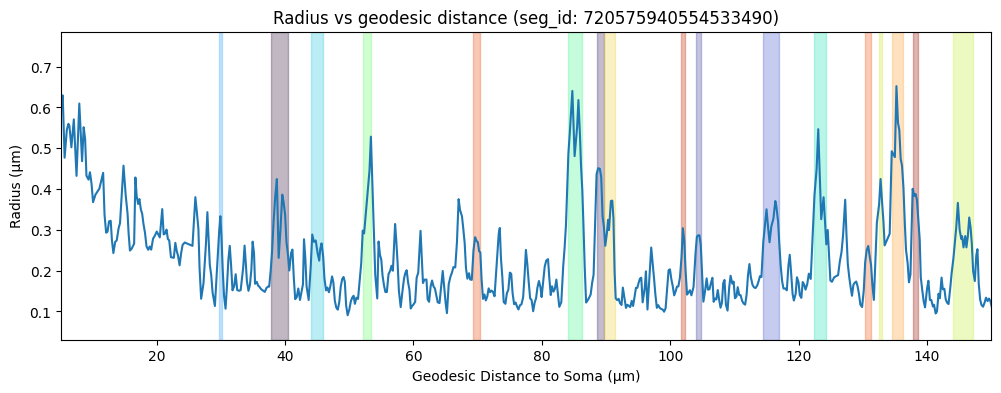

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
bd.visualization.plot_branch_radius_profile(
    geodesic_dists=geodesic_dists_pruned,
    radii=radii_pruned,
    start_ids=start_ids_pruned,
    end_ids=end_ids_pruned,
    ax=ax,
    title=f'Radius vs geodesic distance (seg_id: {seg_id})',
    xmax=150
)
plt.show()